In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm, Normalize
import matplotlib.gridspec as gridspec
import ipywidgets

import discretize

from simpeg.electromagnetics import resistivity as dc

from simpeg import (
     maps,
     utils,
     survey,
     data,
     data_misfit,
     directives,
     seismic,
     optimization,
     regularization,
     inverse_problem,
     inversion,
)

# build model
define model extents, build mesh, define slope surface and add weak clay layer

In [2]:
#define grid extents
extent_x, extent_z = 400, 200

#mesh size
dx = 5
dz = 5

nx = int(np.ceil(extent_x / dx))
nz = int(np.ceil(extent_z / dz))

hx = np.ones(nx) * dx
hz = np.ones(nz) * dz

#create mesh
mesh = discretize.TensorMesh([hx, hz])

model = np.ones(mesh.nC) * 500

cc = mesh.cell_centers
x = cc[:, 0]
z = cc[:, 1]

#define the slope surface 
z_top = z.max()

def slope(x):
    return z_top - 0.5 * (x - x.min())

slope_surface = slope(x)


In [3]:
#deal with "air" above slope surface
air = z > slope_surface
model[air] = 1e8

active_cells = ~air

m_active = 500 * np.ones(active_cells.sum())
active_map = maps.InjectActiveCells(mesh, active_cells, 1e8)

In [4]:
#define weak/low resistivity clay layer 
weak_layer = (
    (z < slope_surface - 15) &
    (z > slope_surface - 25)
)

model[weak_layer] = 10

In [5]:
#verify number of cells and mesh extent
mesh

TensorMesh: 3,200 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     80          0.00        400.00      5.00      5.00    1.00
   y     40          0.00        200.00      5.00      5.00    1.00

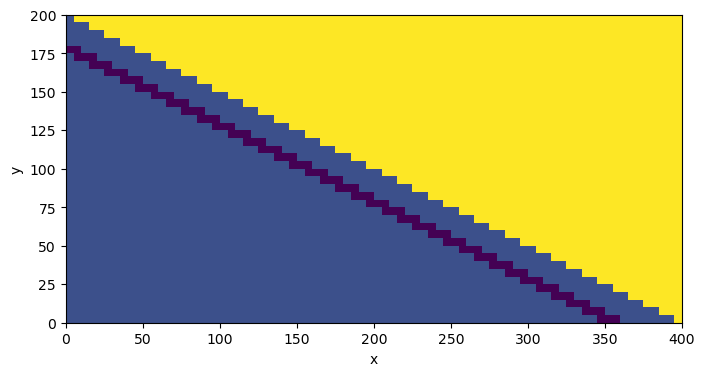

In [6]:
#visualize slope
fig, ax = plt.subplots(figsize=(8, 4))

mesh.plot_image(np.log10(model), ax=ax, grid=False)

ax.set_aspect("equal") 

plt.show()

# configure electrodes
define electrode spacing and layout, assign sources and recievers

In [7]:
#define electrode locations along slope
n_electrodes = 100
electrode_x = np.linspace(5, 395, n_electrodes)
electrode_z = np.interp(electrode_x, x, slope_surface-3)

x_min = mesh.nodes_x.min()
x_max = mesh.nodes_x.max()

electrode_z = slope(electrode_x)

electrode_locations = np.c_[electrode_x, electrode_z]

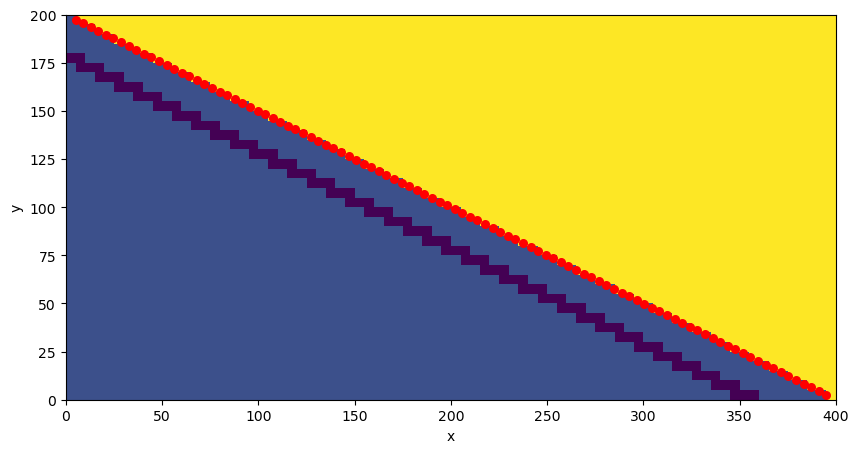

In [8]:
#visualize slope with electrodes along surface
fig, ax = plt.subplots(figsize=(10, 5))

mesh.plot_image(np.log10(model), ax=ax, grid=False)

ax.scatter(electrode_x, electrode_z, c="red", s=30)

ax.set_aspect("equal")

plt.show()

In [9]:
#define A/B and M/N electrodes for dipole-dipole array
source_list = []

for i in range(0, n_electrodes-3, 4):
    A = electrode_locations[i]
    B = electrode_locations[i+1]
    
    for j in range(i+2, n_electrodes-1):
        M = electrode_locations[j]
        N = electrode_locations[j+1]
        
        receivers = dc.receivers.Dipole(M.reshape(1,2), N.reshape(1,2))
        source = dc.sources.Dipole([receivers], location_a=A, location_b=B)
        source_list.append(source)

# forward simulation
conduct the forward simulation to obtain data

In [10]:
#define the survey for the forward simulation
survey = dc.Survey(source_list) 

In [11]:
#set up the simulation
simulation = dc.Simulation2DNodal(
    mesh=mesh,
    survey=survey,
    rhoMap=active_map,
)

#make synthetic data
synthetic_data = simulation.make_synthetic_data(m_active)
print("Number of measurements:", len(synthetic_data.dobs))
print("First 10 simulated voltages:", synthetic_data.dobs[:10])

INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)


Number of measurements: 1225
First 10 simulated voltages: [ 7.47721717e+02 -7.63954791e+02 -5.96815975e-01  5.77725371e+01
 -5.84693654e+01  1.14067484e+01 -1.16460487e+01 -4.40582307e-02
  3.30106796e+00 -3.38550739e+00]


In [12]:
#find the midpoints and spacing of the electrode pairs for plotting the pseudosections
midpoints = []
ABMN_spacing = []

for src in survey.source_list:
    A, B = src.location_a, src.location_b
    for rx in src.receiver_list:
        M, N = rx.locations
        M = M[0]
        N = N[0]
        
        midpoint = (A[0] + B[0] + M[0] + N[0]) / 4
        midpoints.append(midpoint)
        
        spacing = ((M[0] + N[0])/2 - (A[0] + B[0])/2)
        ABMN_spacing.append(spacing)
        
midpoints = np.array(midpoints)
ABMN_spacing = np.array(ABMN_spacing)
synthetic_data_values = synthetic_data.dobs  

In [13]:
# # plot pseudosections 
# fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    
# # plot a psuedosection of the data
# dc.utils.plot_pseudosection(
#     synthetic_data, data_type="apparent resistivity", 
#     plot_type="contourf", data_location=True, ax=ax, 
#     cbar_opts={"pad":0.25}
# )
# ax.set_xlim(core_domain_x)
# ax.set_aspect(1.5)  # some vertical exxageration
# ax.set_xlabel("Northing (m)")

# plt.tight_layout()

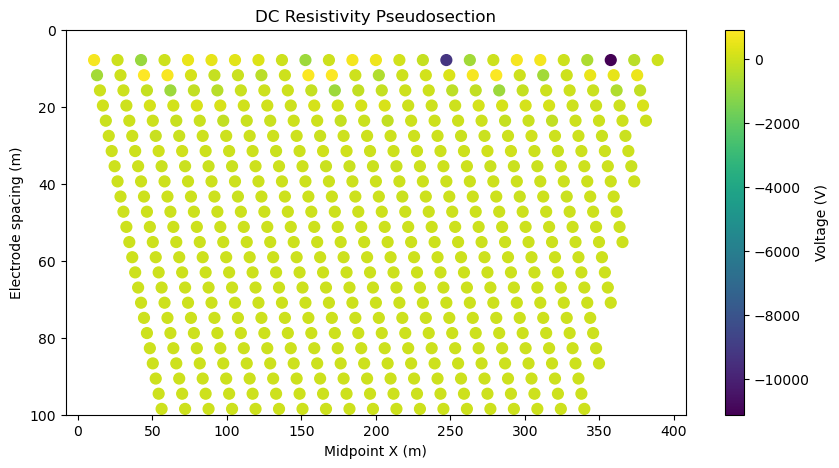

In [14]:
fig, ax = plt.subplots(figsize=(10,5))
sc = ax.scatter(midpoints, ABMN_spacing, c=synthetic_data_values, cmap='viridis', s=60)
plt.colorbar(sc, label='Voltage (V)')

ax.set_ylim(0, 100)
ax.invert_yaxis()
ax.set_xlabel('Midpoint X (m)')
ax.set_ylabel('Electrode spacing (m)')
ax.set_title('DC Resistivity Pseudosection')
plt.show()

# set up inversion
assign noise and configure the inverse problem

Text(0.5, 0, '$log_{10}(|d^{obs}|)$')

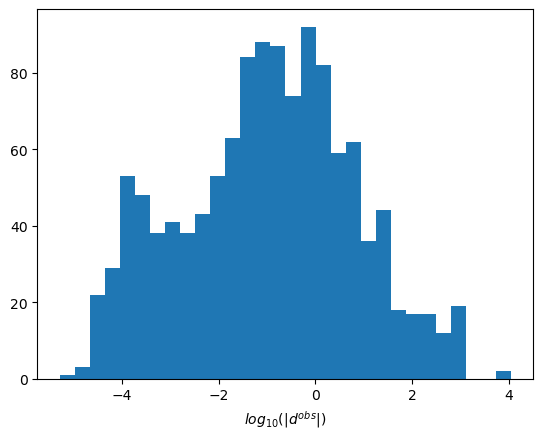

In [15]:
fig, ax = plt.subplots(1, 1)
ax.hist(np.log10(np.abs(synthetic_data.dobs)), 30)
ax.set_xlabel("$log_{10}(|d^{obs}|)$")

In [16]:
#assign relative error and noise
relative_error = 0.05 
noise_floor = 1e-6

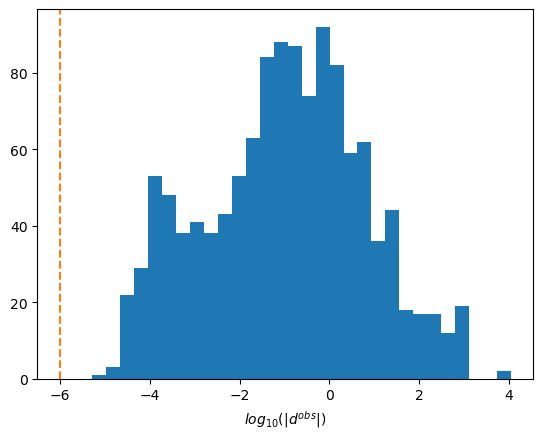

In [17]:
fig, ax = plt.subplots(1, 1)
ax.hist(np.log10(np.abs(synthetic_data.dobs)), 30)
ax.set_xlabel("$log_{10}(|d^{obs}|)$")
ax.axvline(np.log10(noise_floor), linestyle="dashed", color="C1")

In [ ]:
# #assign uncertainty
# #W_d = np.diag(1 / synthetic_data.standard_deviation) 

# synthetic_data.relative_error = relative_error
# synthetic_data.noise_floor = noise_floor

# assert(np.allclose(
#     relative_error * np.abs(synthetic_data.dobs) + noise_floor, 
#     synthetic_data.standard_deviation
#     atol=1e-5
# ))